# Customer Feedback Analysis and Automated Response

## Objective

- This project analyzes customer reviews using Python and Pandas.
- Reviews are identified using rule-based filtering, common complaint keywords are extracted, and Google Gemini is used to generate personalized apology emails.

In [1]:
import pandas as pd
import numpy as np
import re

from collections import Counter

### Step 1: Load the Dataset

- The customer review dataset is loaded using Pandas so that it can be analyzed and processed.

In [2]:
data = pd.read_csv(r"file:///C:\Users\Dell\Documents\Internship%20Assesment\customer_reviews.csv")
data

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...,...
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


### Step 2: Display the First Five Rows

The first five rows are displayed to understand the structure of the dataset.

In [3]:
data.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### Step 3: Check Dataset Size

The shape function returns the number of rows and columns.

In [4]:
data.shape

(23486, 11)

### Step 4: Display Column Names

The column names help identify which features are useful for the analysis.

In [5]:
data.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

### Step 5: Check Data Types

The data types help determine whether each column contains text, numbers, or other information.

In [6]:
data.dtypes

Unnamed: 0                  int64
Clothing ID                 int64
Age                         int64
Title                      object
Review Text                object
Rating                      int64
Recommended IND             int64
Positive Feedback Count     int64
Division Name              object
Department Name            object
Class Name                 object
dtype: object

### Step 6: Check Missing Values

Missing values are identified before cleaning the dataset.

In [7]:
data.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

### Step 7: Remove Unnecessary Columns

The dataset contains several columns that are not required for customer feedback analysis.
Only the relevant columns are retained for this project.

In [8]:
data = data[['Review Text', 'Rating']]

In [9]:
data.head()

,Review Text,Rating
0,Absolutely wonderful - silky and sexy and comf...,4
1,Love this dress! it's sooo pretty. i happene...,5
2,I had such high hopes for this dress and reall...,3
3,"I love, love, love this jumpsuit. it's fun, fl...",5
4,This shirt is very flattering to all due to th...,5


### Step 8: Remove Missing Reviews

Rows without review text cannot be analyzed or used to generate AI responses.
These rows are removed from the dataset.

In [10]:
data = data.dropna(subset=['Review Text'])

In [11]:
data.isnull().sum()

Review Text    0
Rating         0
dtype: int64

In [12]:
data.shape

(22641, 2)

### Step 9: Convert Reviews to Lowercase

All review text is converted to lowercase to ensure consistency during text analysis.

In [13]:
data['Review Text'] = data['Review Text'].str.lower()

In [14]:
data.head()

,Review Text,Rating
0,absolutely wonderful - silky and sexy and comf...,4
1,love this dress! it's sooo pretty. i happene...,5
2,i had such high hopes for this dress and reall...,3
3,"i love, love, love this jumpsuit. it's fun, fl...",5
4,this shirt is very flattering to all due to th...,5


### Step 10: Remove Special Characters

Special characters and punctuation are removed to simplify keyword extraction.

In [15]:
data['Review Text'] = data['Review Text'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

### Step 11: Remove Extra Spaces

Extra spaces are removed to improve text consistency.

In [16]:
data['Review Text'] = data['Review Text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [17]:
data.head()

,Review Text,Rating
0,absolutely wonderful silky and sexy and comfor...,4
1,love this dress its sooo pretty i happened to ...,5
2,i had such high hopes for this dress and reall...,3
3,i love love love this jumpsuit its fun flirty ...,5
4,this shirt is very flattering to all due to th...,5


### Step 12: Filter Critical Reviews

Critical reviews are identified using a rule-based approach.
Reviews with a rating of 1 or 2 are considered critical.

In [18]:
critical_reviews = data[data['Rating'] <= 2]

In [19]:
critical_reviews.head()

,Review Text,Rating
5,i love tracy reese dresses but this one is not...,2
22,first of all this is not pullover styling ther...,2
26,i have been waiting for this sweater coat to s...,2
33,i ordered this months ago and it finally came ...,2
56,i am pregnant and i thought this would be a gr...,2


## Number of Critical Reviews

The total number of reviews with ratings less than or equal to 2 is calculated.

In [20]:
critical_reviews.shape

(2370, 2)

In [21]:
critical_reviews['Rating'].value_counts()

Rating
2    1549
1     821
Name: count, dtype: int64

### Step 13: Combine Critical Reviews

All critical reviews are combined into one text string for keyword analysis.

In [22]:
all_reviews = " ".join(critical_reviews["Review Text"])

### Step 14: Split Reviews into Words

The combined review text is split into individual words for frequency analysis.

In [23]:
words = all_reviews.split()

In [24]:
words[:20]

['i',
 'love',
 'tracy',
 'reese',
 'dresses',
 'but',
 'this',
 'one',
 'is',
 'not',
 'for',
 'the',
 'very',
 'petite',
 'i',
 'am',
 'just',
 'under',
 'feet',
 'tall']

### Step 15: Count Word Frequency

Python's Counter is used to count how frequently each word appears in the critical reviews.

In [25]:
word_counts = Counter(words)

### Step 16: Most Common Words

The most frequently occurring words are displayed.

In [26]:
word_counts.most_common(20)

[('the', 9133),
 ('i', 6025),
 ('it', 4740),
 ('and', 4677),
 ('a', 3803),
 ('this', 2838),
 ('is', 2776),
 ('to', 2574),
 ('was', 2379),
 ('in', 2140),
 ('but', 1886),
 ('on', 1806),
 ('of', 1641),
 ('not', 1439),
 ('so', 1240),
 ('for', 1224),
 ('dress', 1117),
 ('like', 1048),
 ('that', 976),
 ('my', 972)]

### Step 17: Remove Stop Words

Common English stop words are removed so that only meaningful complaint keywords remain.

In [27]:
stop_words = {
    "the","is","a","an","and","or","to","of","in","on","for","this","that",
    "it","i","my","was","were","be","been","are","am","as","at","with",
    "have","has","had","but","if","so","not","you","your","we","our","they",
    "their","them","he","she","his","her","its","me","do","does","did",
    "from","by","all","too","very","can","will","would","just"
}

In [28]:
filtered_words = [word for word in words if word not in stop_words]

In [29]:
word_counts = Counter(filtered_words)

In [30]:
word_counts.most_common(20)

[('dress', 1117),
 ('like', 1048),
 ('top', 821),
 ('fabric', 707),
 ('fit', 679),
 ('size', 670),
 ('back', 606),
 ('look', 514),
 ('ordered', 509),
 ('small', 503),
 ('im', 491),
 ('really', 474),
 ('love', 455),
 ('when', 453),
 ('out', 439),
 ('material', 426),
 ('wear', 425),
 ('shirt', 414),
 ('one', 398),
 ('looks', 397)]

### Step 18: Remove Generic Product Words

Common product names and generic words are removed so that the analysis focuses on complaint-related keywords.

In [31]:
custom_words = {
    "dress", "top", "shirt", "wear", "looks", "look",
    "like", "really", "im", "one", "back", "out",
    "love", "when"
}

In [32]:
final_words = [word for word in filtered_words if word not in custom_words]

In [33]:
final_counts = Counter(final_words)

In [34]:
top_keywords = pd.DataFrame(
    final_counts.most_common(10),
    columns=["Keyword", "Frequency"]
)

top_keywords

,Keyword,Frequency
0,fabric,707
1,fit,679
2,size,670
3,ordered,509
4,small,503
5,material,426
6,much,381
7,color,377
8,up,377
9,looked,375


### Step 19: EDA of Top Complaint Keywords

A bar chart is created to visualize the most common complaint-related keywords.

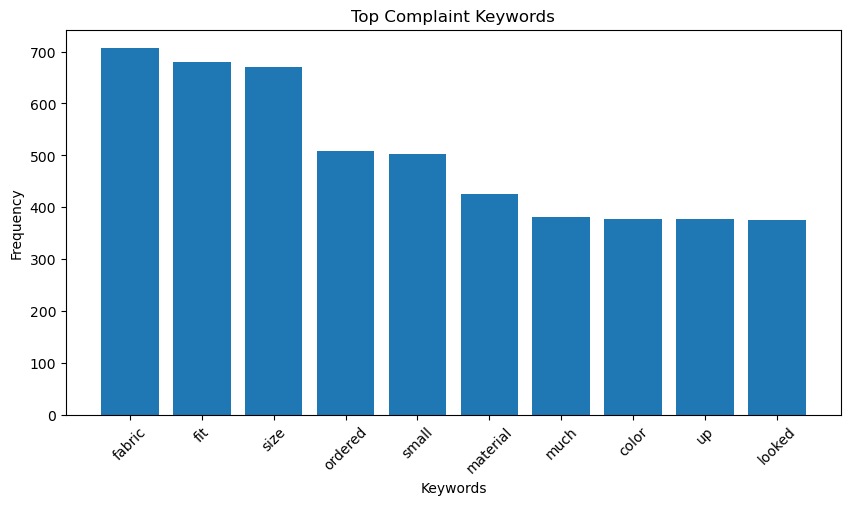

In [35]:
import matplotlib.pyplot as plt

top_words = final_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)

plt.title("Top Complaint Keywords")
plt.xlabel("Keywords")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## Insights

- Fabric-related issues are among the most common complaints.
- Customers frequently mention fabric , fit and size problems.
- Ordering and material quality also appear regularly in negative reviews.
- These insights can help the customer support team prioritize recurring issues.

### Step 20: Select the Most Detailed Critical Reviews

The three most detailed critical reviews are selected based on review length.
Longer reviews generally provide more information for generating personalized responses.

In [36]:
critical_reviews = critical_reviews.copy()

critical_reviews["Review_Length"] = critical_reviews["Review Text"].str.len()

top_reviews = critical_reviews.sort_values(
    by="Review_Length",
    ascending=False
).head(3)

top_reviews[["Review Text", "Rating", "Review_Length"]]

,Review Text,Rating,Review_Length
10290,i was excited to receive this coat for my annu...,2,496
2091,i purchased this top in the rose and steel blu...,1,495
23117,i was very shocked to receive this dress with ...,1,495


### Step 21: Display the Reviews

In [37]:
for i, review in enumerate(top_reviews["Review Text"], start=1):
    print(f"\nReview {i}\n")
    print(review)
    print("-" * 100)


Review 1

i was excited to receive this coat for my annual travel to switzerland but hesitated to order it online without seeing it first due to the price it arrived last night with the buttons falling off and a large hole in the front pocket the lining inside is has a very cheap plasticky feel and i can also see small rips possibly forming in the lining in addition the collar on the coat is extremely bulky and the shoulders are padded underneath the fur which makes ones shoulders appear like a lineba
----------------------------------------------------------------------------------------------------

Review 2

i purchased this top in the rose and steel blue colors even though the majority of reviews says it shrinks even when you wash per the instructions i called the local retailer store first to see if it could be returned if this happened and they said yes no problem well the reviews are correct i washed just the rose colored top so i could compare it to the steel blue if it did sh

### Step 23 — Install the Library

In [61]:
!pip install -U openai

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.6 MB 3.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.6 MB/s eta 0:00:00

  Attempting uninstall: typing-extensions

    Found existing installation: typing_extensions 4.12.2

    Uninstalling typing_extensions-4.12.2:

   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------------------------------------- 0/2 [typing-extensions]
   ---------

In [62]:
from openai import OpenAI

In [66]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="YOUR_API_KEY",
)

In [67]:
response = client.chat.completions.create(
    model="meta-llama/llama-3.1-8b-instruct",
    messages=[
        {
            "role":"user",
            "content":"Say hello."
        }
    ]
)

print(response.choices[0].message.content)

Hello! How can I assist you today?


### Step 24: Generate Personalized AI Response Emails

Each critical customer review is sent to a Generative AI model through the OpenRouter API.

The model generates a personalized apology email for every customer complaint.

In [68]:
generated_emails = []

for review in top_reviews["Review Text"]:

    prompt = f"""
You are a professional Customer Support Agent.

Customer Complaint:

{review}

Write a personalized customer apology email.

Requirements:
- Start with "Dear Customer,"
- Apologize sincerely.
- Mention the customer's specific complaints.
- Assure them the issue will be investigated.
- Offer assistance.
- Keep the email professional.
- Keep it around 120–180 words.
- End politely.

Do not use bullet points.
"""

    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-8b-instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    generated_emails.append(
        response.choices[0].message.content
    )

In [69]:
for i, email in enumerate(generated_emails, start=1):

    print("=" * 100)
    print(f"EMAIL {i}")
    print("=" * 100)
    print(email)
    print("\n")

EMAIL 1
Dear Customer,

I am writing to offer my sincerest apologies for the disappointing condition of the coat you received. We understand that you were expecting a high-quality item that met your expectations, especially considering the price and the fact that you were hesitant to order it online.

I apologize that the coat arrived with buttons falling off, a large hole in the front pocket, and a lining with a cheap plasticky feel, along with small rips forming. Additionally, the bulky collar and padded shoulders under the fur are not what you should expect from a coat at this price point and create an awkward fit.

I want to assure you that we take your complaints very seriously and will be investigating the issue immediately. Our team will look into the quality control process to prevent similar issues in the future. In the meantime, we would like to offer assistance to make things right. Please reply to this email so we can discuss further how we can repair or exchange the coat t

### Step 30 — Storing Everything in a DataFrame

In [71]:
results = top_reviews.copy()

results["AI Response"] = generated_emails

results

,Review Text,Rating,Review_Length,AI Response
10290,i was excited to receive this coat for my annu...,2,496,"Dear Customer,\n\nI am writing to offer my sin..."
2091,i purchased this top in the rose and steel blu...,1,495,"Dear Customer,\n\nI want to start by sincerely..."
23117,i was very shocked to receive this dress with ...,1,495,"Dear Customer,\n\nI am truly sorry for the dis..."


In [72]:
results = results[
    [
        "Rating",
        "Review_Length",
        "Review Text",
        "AI Response"
    ]
]

results

,Rating,Review_Length,Review Text,AI Response
10290,2,496,i was excited to receive this coat for my annu...,"Dear Customer,\n\nI am writing to offer my sin..."
2091,1,495,i purchased this top in the rose and steel blu...,"Dear Customer,\n\nI want to start by sincerely..."
23117,1,495,i was very shocked to receive this dress with ...,"Dear Customer,\n\nI am truly sorry for the dis..."


# Conclusion

This project successfully analyzed customer feedback from an e-commerce clothing dataset.

Key achievements include:

- Cleaned and preprocessed customer review data.
- Identified critical customer complaints using rule-based filtering.
- Extracted the most frequent complaint keywords.
- Visualized common customer issues.
- Generated personalized apology emails using a Generative AI API.

This workflow demonstrates how data analytics and Generative AI can work together to improve customer support and enhance customer satisfaction.

# Business Insights

1. Fabric quality is one of the most frequently mentioned issues.

2. Customers often complain about sizing and fitting problems.

3. Product material and ordering experience contribute significantly to negative reviews.

4. Personalized AI-generated responses can help customer support teams respond faster while maintaining a professional tone.

5. Businesses can use these insights to improve product quality and customer satisfaction.